Cleaned column names: ['age', 'gender', 'educationlevel', 'jobtitle', 'yearsofexperience', 'salary']


,age,gender,educationlevel,jobtitle,yearsofexperience,salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                6702 non-null   float64
 1   gender             6702 non-null   object 
 2   educationlevel     6701 non-null   object 
 3   jobtitle           6702 non-null   object 
 4   yearsofexperience  6701 non-null   float64
 5   salary             6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
None

Numeric Columns Detected: ['age', 'yearsofexperience', 'salary']


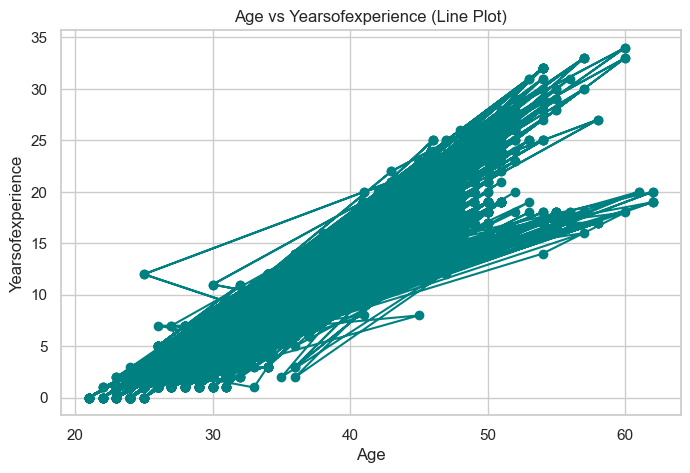

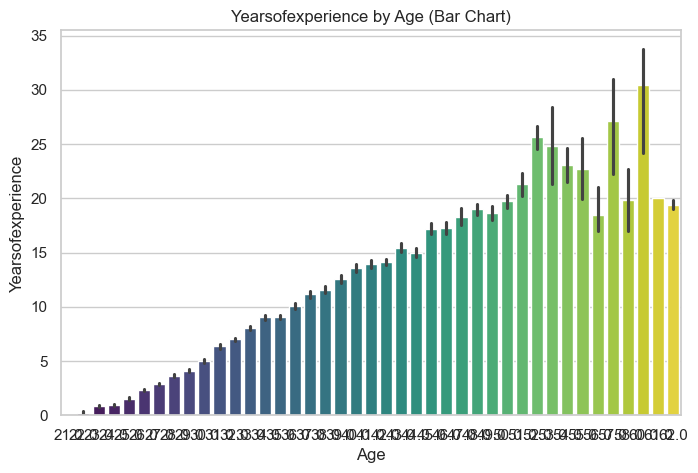

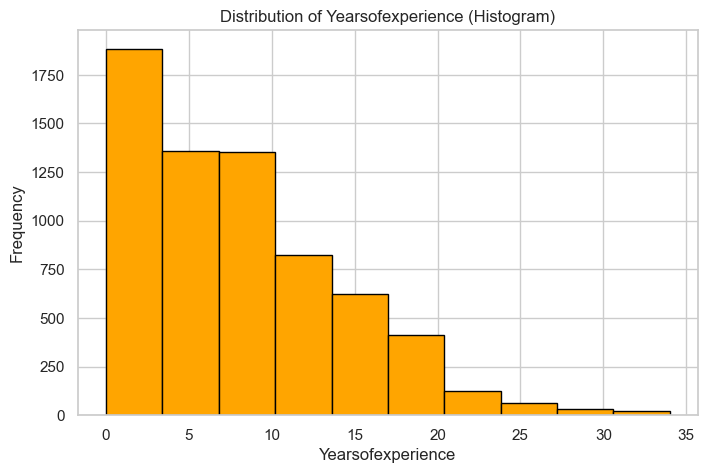

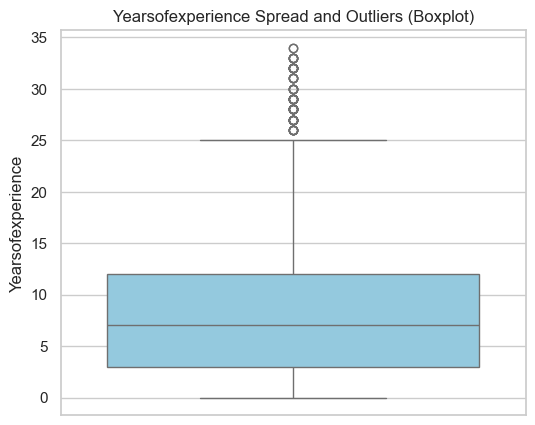

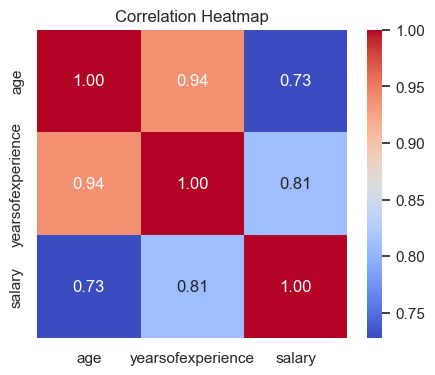

In [4]:
# -------------------------------------------
# Placement Dataset Visualization (Safe Version)
# -------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
data = pd.read_csv(r"D:\Aditya\Salary_Data.csv")

# Clean and normalize column names
data.columns = data.columns.str.strip().str.replace(" ", "").str.lower()
print("Cleaned column names:", list(data.columns))

# Show data info
display(data.head())
print("\nData Info:")
print(data.info())

# Keep only numeric columns for plotting
num_data = data.select_dtypes(include=['int64', 'float64'])
print("\nNumeric Columns Detected:", list(num_data.columns))

# If fewer than 2 numeric columns exist, display warning
if len(num_data.columns) < 2:
    raise ValueError("Dataset must contain at least 2 numeric columns to plot.")

xcol, ycol = num_data.columns[0], num_data.columns[1]

# -------------------------------------------
# 1. LINE PLOT
# -------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(num_data[xcol], num_data[ycol], marker='o', color='teal')
plt.title(f"{xcol.title()} vs {ycol.title()} (Line Plot)")
plt.xlabel(xcol.title())
plt.ylabel(ycol.title())
plt.grid(True)
plt.show()

# -------------------------------------------
# 2. BAR CHART
# -------------------------------------------
# -------------------------------------------
# 2. BAR CHART (Fixed FutureWarning)
# -------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(x=xcol, y=ycol, data=num_data, hue=xcol, palette='viridis', legend=False)
plt.title(f"{ycol.title()} by {xcol.title()} (Bar Chart)")
plt.xlabel(xcol.title())
plt.ylabel(ycol.title())
plt.show()


# -------------------------------------------
# 3. HISTOGRAM
# -------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(num_data[ycol], bins=10, color='orange', edgecolor='black')
plt.title(f"Distribution of {ycol.title()} (Histogram)")
plt.xlabel(ycol.title())
plt.ylabel("Frequency")
plt.show()

# -------------------------------------------
# 4. BOXPLOT
# -------------------------------------------
plt.figure(figsize=(6, 5))
sns.boxplot(y=num_data[ycol], color='skyblue')
plt.title(f"{ycol.title()} Spread and Outliers (Boxplot)")
plt.ylabel(ycol.title())
plt.show()

# -------------------------------------------
# 5. HEATMAP (Correlation)
# -------------------------------------------
plt.figure(figsize=(5, 4))
corr = num_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
